# Data Science in Earth Observation - Classification

## Agenda

### Part 1
1. [Introduction](#1.-Introduction)
2. [Meet the Data](#2.-Meet-the-Data)
3. [Machine Learning: Random Forest Classifier](#3.-Machine-Learning:-Random-Forest-Classifier)
4. [Other ML Models](#4.-Other-ML-Models)
5. [Deep Learning](#5.-Deep-Learning)
6. [DL Preprocessing](#6.-DL-Preprocessing)
7. [Residual Networks](#7.-Residual-Networks)

## 1. Introduction: So2Sat LCZ42

By 2050, Berlin summers could be as hot as in Canberra, Australia. Pankow, a district in the city’s north, has already declared a climate emergency in 2019 and is planning ahead. It is planting trees from the Mediterranean that can withstand the heat, and has calculated computer simulations for sunshine and cold air corridors for the construction of 1200 new apartments. A few changes, like swapping asphalt and concrete that store heat against greenery that soaks up water and provides shade, can make a difference on the local scale. Many of these changes on a local scale then make a difference on the bigger scale.

To understand local climate in cities, scientists have developed the Local Climate Zone classification scheme, as part of the So2Sat project. The aim is to create a 4D urban map of the world.

It differentiates between 17 zones based mainly on surface structures (such as building and tree density) as well as surface cover (green, pervious soils versus impervious gray surfaces). There are algorithms that calculate these maps from freely available satellite imagery, but there’s still room for improvement by adapting or developing suitable and advanced Convolutional Neural Network (CNN) architectures that generalize well.

The outcome of So2Sat will be the first and unique global and consistent spatial data set on urban morphology (3D/4D) of settlements, and a multidisciplinary application derivate assessing population density. This is seen as a giant leap for urban geography research, as well as for formation of opinions for stakeholders based on resilient data.

![Data set](so2sat_dataset.png)


... and this is the data set paper:
```
@article{zhu2020so2sat,
  title={So2Sat LCZ42: a benchmark data set for the classification of global local climate zones [Software and Data Sets]},
  author={Zhu, Xiao Xiang and Hu, Jingliang and Qiu, Chunping and Shi, Yilei and Kang, Jian and Mou, Lichao and Bagheri, Hossein and Haberle, Matthias and Hua, Yuansheng and Huang, Rong and others},
  journal={IEEE Geoscience and Remote Sensing Magazine},
  volume={8},
  number={3},
  pages={76--89},
  year={2020},
  publisher={IEEE}
}
```

## 2. Meet the Data

The *So2Sat LCZ42* data set is an *Earth observation* image classification data set. It contains co-registered image patches from Sentinel-1 (10 multi-spectral bands) and Sentinel-2 (8 bands) satellite sensors, all assigned to one of the 17 *local climate zones* (LCZ) classes.

The LCZ classes are as follows: 
1) compact high-rise, 
2) compact mid-rise, 
3) compact low-rise,
4) open high-rise,
5) open mid-rise,
6) open low-rise,
7) lightweight low-rise,
8) large low-rise,
9) sparsely built, 
10) heavy industry,
11) dense trees,
12) scattered tree, 
13) bush, scrub,
14) low plants,
15) bare rock or paved,
16) bare soil or sand, and 
17) water

The data set is split into training (352,366 images), validation (24,188) and test (24,119).

It is important to note that two various pools of cities were used to build So2Sat LCZ42. 32 cities around the globe were selected to form the training set, while samples from 10 different cites were used for the validation and test set, with a geographical split (east and west).

![Sample](so2sat_sample.png)

In [ ]:
# Uncomment the following lines to install the required packages
# import sys
# !{sys.executable} -m pip install -r requirements.txt

Load the required packages

In [1]:
import h5py
import numpy as np

import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib import colormaps

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import MinMaxScaler, StandardScaler

import tensorflow as tf

I0000 00:00:1778175054.424267   35799 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1778175054.466747   35799 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1778175055.504791   35799 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [2]:
# this should match the name of the downloaded data set
filename = 'data/subset_lcz42.h5'

dataset = h5py.File(filename, 'r')

# show the content names
print(list(dataset.keys()))

['label', 'sen1', 'sen2']


### Labels

In [3]:
# load the labels
labels = np.array(dataset['label'])

# show the shape
print("Labels shape: " + str(labels.shape))

# print the labels
print(labels[0:10,:])

Labels shape: (2400, 17)
[[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]


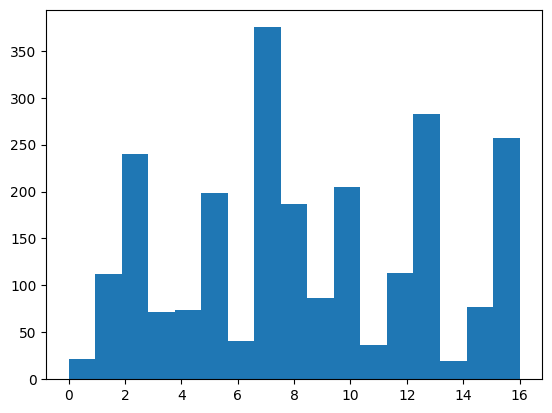

In [4]:
# Check the data distribution
plt.hist(np.argmax(labels, axis=1), bins=17)

# let's get a sample from each class
class_sample = np.argmax(labels, axis=0)
# print(class_sample)

### Sentinel-1

The data set contains the following channels:
1) the real part of the unfiltered VH channel
2) the imaginary part of the unfiltered VH channel
3) the real part of the unfiltered VV channel
4) the imaginary part of the unfiltered VV channel
5) the intensity of the refined Lee filtered VH channel
6) the intensity of the refined Lee filtered VV channel
7) the real part of the refined Lee filtered covariance matrix off-diagonal element
8) the imaginary part of the refined Lee filtered covariance matrix off-diagonal element

Sentinel-1 shape: (2400, 32, 32, 8)


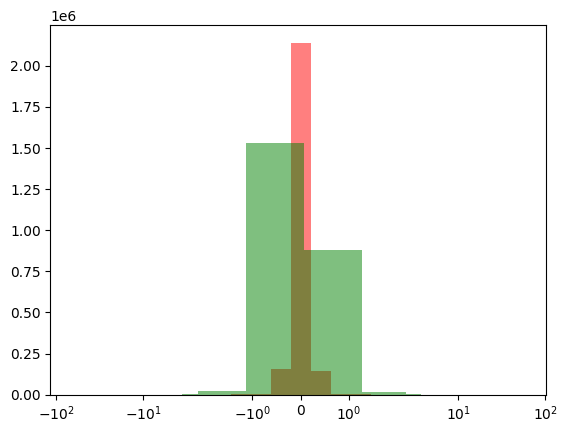

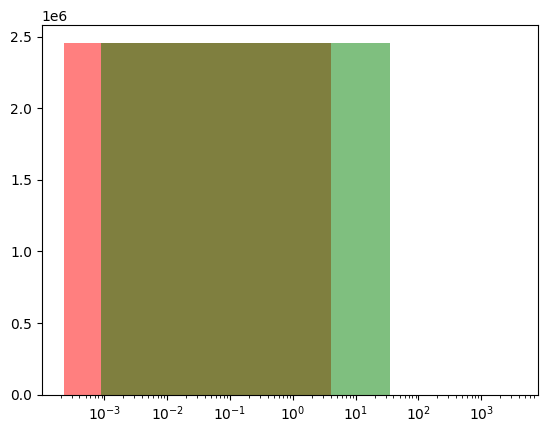

In [5]:
# load Sentinel-1 data
sen1 = np.array(dataset['sen1'])

print("Sentinel-1 shape: " + str(sen1.shape))

plt.hist(sen1[:,:,:,0].flatten(), label="1", color="red", alpha=0.5, bins=100)
plt.hist(sen1[:,:,:,2].flatten(), label="3", color="green", alpha=0.5, bins=100)
plt.xscale('symlog')
plt.show()
plt.hist(sen1[:,:,:,4].flatten(), label="5", color="red", alpha=0.5, bins=100)
plt.hist(sen1[:,:,:,5].flatten(), label="6", color="green", alpha=0.5, bins=100)
plt.xscale('log')
plt.show()


/tmp/ipykernel_35799/172568809.py:18: RuntimeWarning: invalid value encountered in log
  band1 = c4 + np.log(c1 - np.log(c6 / (c3 + 2.5 * VV)) + np.log(c6 / (c3 + 1.5 * VH)))
/tmp/ipykernel_35799/172568809.py:20: RuntimeWarning: invalid value encountered in log
  band3 = 0.8 - np.log(c6 / (c5 - c7 * VV))
/tmp/ipykernel_35799/172568809.py:32: RuntimeWarning: invalid value encountered in cast
  return tc.astype('uint8')


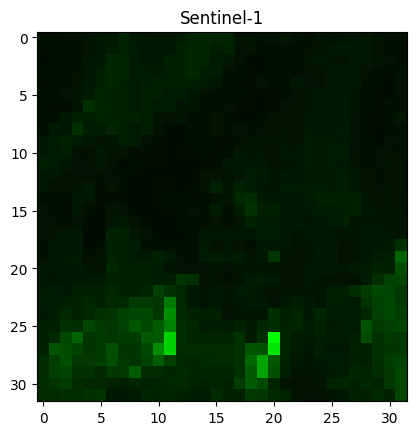

In [6]:
def false_color(X):
    VH = X[:,:,4]
    VV = X[:,:,5]
    
    c1 = 10e-4;
    c2 = 0.01;
    c3 = 0.02;
    c4 = 0.03;
    c5 = 0.045;
    c6 = 0.05;
    c7 = 0.9;
    c8 = 0.25;

    # Enhanced or non-enhanced option (set to "true" if you want enhanced)
    enhanced = True;

    if (enhanced): 
        band1 = c4 + np.log(c1 - np.log(c6 / (c3 + 2.5 * VV)) + np.log(c6 / (c3 + 1.5 * VH)))
        band2 = c6 + np.exp(c8 * (np.log(c2 + 2 * VV) + np.log(c3 + 7 * VH)))
        band3 = 0.8 - np.log(c6 / (c5 - c7 * VV))
    else:
        band1 = c4 + np.log(c1 - np.log(c6 / (c3 + 2 * VV)))
        band2 = c6 + np.exp(c8 * (np.log(c2 + 2 * VV) + np.log(c3 + 5 * VH)))
        band3 = 1 - np.log(c6 / (c5 - c7 * VV))

    band1 = band1 / (band1.max()/255.0)
    band2 = band2 / (band2.max()/255.0)
    band3 = band3 / (band3.max()/255.0)
        
    tc = np.dstack((band1, band2, band3))
    
    return tc.astype('uint8')

plt.imshow(false_color(sen1[class_sample[0],:,:,:]))
plt.title('Sentinel-1')

plt.show()

/tmp/ipykernel_35799/172568809.py:18: RuntimeWarning: invalid value encountered in log
  band1 = c4 + np.log(c1 - np.log(c6 / (c3 + 2.5 * VV)) + np.log(c6 / (c3 + 1.5 * VH)))
/tmp/ipykernel_35799/172568809.py:20: RuntimeWarning: invalid value encountered in log
  band3 = 0.8 - np.log(c6 / (c5 - c7 * VV))
/tmp/ipykernel_35799/172568809.py:32: RuntimeWarning: invalid value encountered in cast
  return tc.astype('uint8')


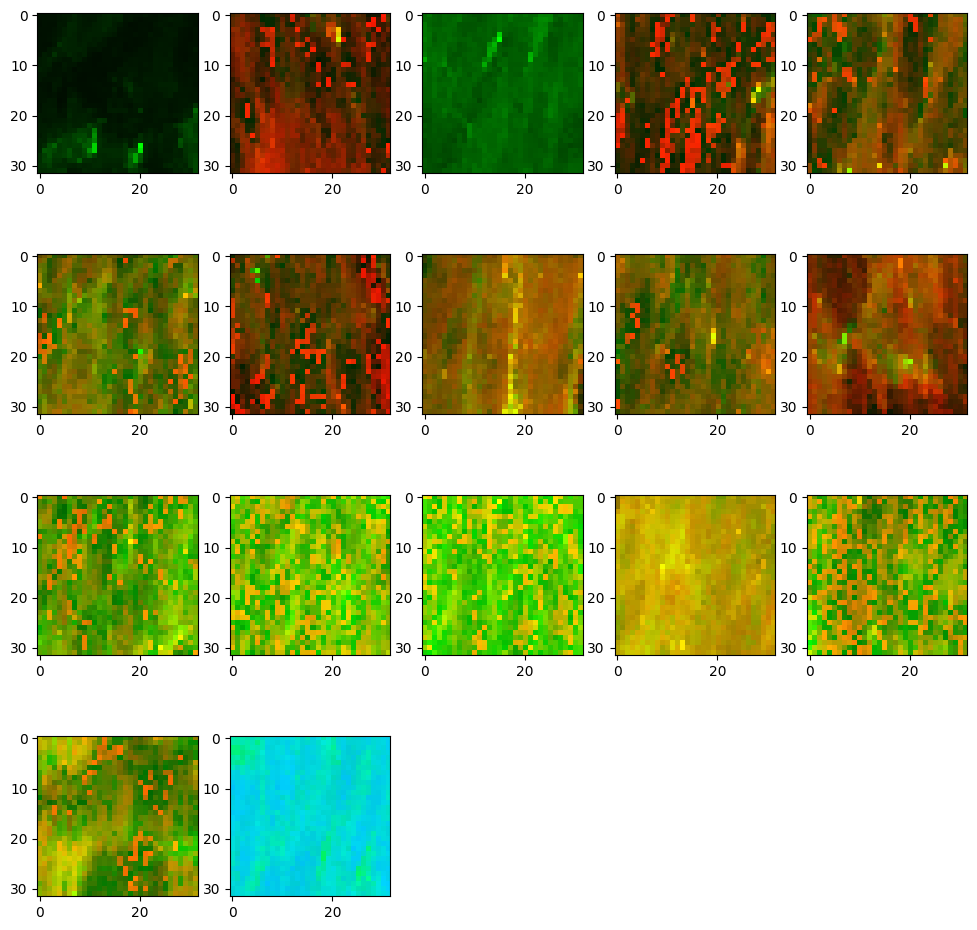

In [7]:
fig=plt.figure(figsize=(12, 12))

for i in range(17):
    fig.add_subplot(4, 5, i+1)
    plt.imshow(false_color(sen1[class_sample[i],:,:,:]))

plt.show()

### Do it yourself

Implement the radar vegetation indexing for visualization of Sentinel-1 data (for the [algorithm](https://custom-scripts.sentinel-hub.com/custom-scripts/sentinel-1/radar_vegetation_index_code_dual_polarimetric/), please refer to Sentinel Hub), and check some results.

In [ ]:
#def calc_rvi(X):
#    VH = X[:,:,4]
#    VV = X[:,:,5]   
#    
#    dop = (VV / (VV + VH))
#    m = 1 - dop # dop = degree of polarization
#    radar_vegetation_index = (np.sqrt(dop))*((4*VH)/(VV+VH))
#    radar_vegetation_index = ((4*VH)/(VV+VH))
#    
#    return radar_vegetation_index



### Sentinel-2

Sentinel-2 Bands in So2Sat LCZ 42
1) Band B2 (Blue), 10m GSD
2) Band B3 (Green), 10m GSD
3) Band B4 (Red), 10m GSD
4) Band B5, upsampled to 10m from 20m GSD
5) Band B6, upsampled to 10m from 20m GSD
6) Band B7, upsampled to 10m from 20m GSD
7) Band B8, 10m GSD
8) Band B8a, upsampled to 10m from 20m GSD
9) Band B11, upsampled to 10m from 20m GSD
10) and Band B12, upsampled to 10m from 20m GSD

In [ ]:
# load Sentinel-2 data
sen2 = np.array(dataset['sen2'])

print("Sentinel-2 shape: " + str(sen2.shape))

plt.hist(sen2[:,:,:,0].flatten(), color="blue", label="B2", alpha=0.7, bins=100)
plt.hist(sen2[:,:,:,1].flatten(), color="green", label="B3", alpha=0.7, bins=100)
plt.hist(sen2[:,:,:,2].flatten(), color="red", label="B4", alpha=0.7, bins=100)

cmap = colormaps['plasma']
plasma_colors = cmap(np.linspace(0, 1, 7))

band_labels = ["B5", "B6", "B7", "B8", "B8a", "B11", "B12"]

for band in range(3,10):
    plt.hist(sen2[:,:,:,band].flatten(), color=plasma_colors[band-3,], label=band_labels[band-3], alpha=0.7, bins=100)
plt.yscale('symlog')
plt.legend()
plt.show()

In [ ]:
def true_color(X):
    """ Define True Color Sentinel image    
    The function returns the MinMax scaled RGB bands.
    Matplot convention RGB [0, 255]    
    """    
    blue = X[:,:,0] / (X[:,:,0].max()/255.0)
    green = X[:,:,1] / (X[:,:,1].max()/255.0)
    red = X[:,:,2] / (X[:,:,2].max()/255.0)
    
    tc = np.dstack((red, green, blue))     
    
    return tc.astype('uint8')

# show one patch
plt.imshow(true_color(sen2[class_sample[0],:,:,0:3]))
plt.title('Sentinel-2')

plt.show()


In [ ]:
fig=plt.figure(figsize=(12, 12))

for i in range(17):
    fig.add_subplot(4, 5, i+1)
    plt.imshow(true_color(sen2[class_sample[i],:,:,:]))

plt.show()

### Do it yourself

The Normalized difference vegetation index (NDVI) is a simple, but effective index for quantifying green vegetation. It normalizes green leaf scattering in Near Infra-red wavelengths with chlorophyll absorption in red wavelengths.

It is defined as

$$ NDVI = Index(NIR, RED) = (NIR - RED) / (NIR + RED) $$

For Sentinel-2, NIR = B8 and RED = B4

Implement the NDVI and check some Sentinel-2 images.

## 3. Machine Learning: Random Forest Classifier

Machine learning: A computer program is said to learn from experience E with respect to some task T and some performance measure P, if its performance on T, as measured by P, improves with experience E (*Tom M. Michell, 1997*).


A random forest is a meta estimator that fits a number of classifying decision trees on various sub-samples of the dataset and uses averaging to improve the predictive accuracy and control over-fitting.

![Random Forest](random-forest.png)

In [ ]:
# The random forest expects a vector of features. Therefore,
# we concatenate all bands and pixels
number_samples = sen2.shape[0]
X = np.reshape(sen2, (number_samples, 32 * 32 * 10))

print("Post-processed Sentinel-2 data shape: ", X.shape)

# Let us split the data into train and test
TRAIN_SPLIT = int(number_samples * .8)

X_train = X[:TRAIN_SPLIT,:]
X_test = X[TRAIN_SPLIT:,:]



In [ ]:
# The labels are one hot encoded, but the random forest requires
# the class number
y_train = np.argmax(labels[0:TRAIN_SPLIT,:], axis=1)
y_test = np.argmax(labels[TRAIN_SPLIT:2400,:], axis=1)

print("Post-processed train labels shape: ", y_train.shape)

In [ ]:
rf_classifier = RandomForestClassifier(random_state=0)

rf_classifier.fit(X_train, y_train)

In [ ]:
y_pred_rf = rf_classifier.predict(X_test)

In [ ]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf)
plt.show()

acc_rf = accuracy_score(y_test, y_pred_rf)
print("Accuracy Random Forest Classifier: ", acc_rf)

### Do it yourself

Train a random forest to predict the local climate zone using Sentinel-1 (or NDVI) images.

In [ ]:
print(sen1.shape)
number_samples = sen1.shape[0]
Z = np.reshape(sen1, (number_samples, 32 * 32 * 8))

# Continue...

## 4. Other ML Models

There are multiple ML models for classification, including both supervised and unsupervised methods. For example, [here](https://scikit-learn.org/stable/auto_examples/classification/plot_classifier_comparison.html) you can check several classifiers being compared.


In [ ]:
svm_classifier = SVC()
svm_classifier.fit(X_train, y_train)

In [ ]:
y_pred_svm = svm_classifier.predict(X_test)

In [ ]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_svm)
plt.show()

acc_svm = accuracy_score(y_test, y_pred_svm)
print("Accuracy SVM Classifier: ", acc_svm)

### Do it yourself

Select another classifier, e.g., Nearest Neighbors, AdaBoost, Naive Bayes, etc., and compare the results.

## 5. Deep Learning

The human brain is a *machine* capable of performing very complex tasks, such as pattern recognition, motor control of a limb or perception of sensory stimuli, much faster than any machine invented by man. For this reason, great efforts have been (and continue to be) made to understand how they work. 

This machine is made up of about 100 trillion neurons (cells of the nervous system specialized in the reception and conduction of stimuli), which communicate with each other, forming complex circuits, which are capable of carrying out brain function. This biological model was the inspiration for McCulloch and Pitts to propose a [new computer model](https://www.cs.cmu.edu/~./epxing/Class/10715/reading/McCulloch.and.Pitts.pdf) in 1943: the *artificial neural network* (ANN).

An ANN is a network of computer units (neurons) connected to each other, where each unit performs a calculation from an input and communicates its result (output) to the connected units. Typically, the connections are weighted, which indicates how strong the connection between two units is. Also, the calculation units are usually grouped into modules or layers. ANNs have properties and capabilities that are very useful for solving complex problems, highlighting its nonlinearity, adaptability, fault tolerance, among others. Thanks to these properties, it has been possible to overcome the results obtained in multiple problems.

![Artificial neural network](ann.png)
    
Deep-learning methods are representation-learning methods with multiple levels of representation, obtained by composing simple but non-linear modules that each transform the representation at one level (starting with the raw input) into a representation at a higher, slightly more abstract level. With the composition of enough such transformations, very complex functions can be learned. *Yann LeCun, Yoshua Bengio and Geoffrey Hinton, 2015*

![Deep Learning](deep-learning.png)


In [ ]:
Z_train = sen2[:TRAIN_SPLIT,:,:,:]
Z_test = sen2[TRAIN_SPLIT:,:,:,:]

print("Train shape: ", Z_train.shape, y_train.shape)

In [ ]:
simple_model = tf.keras.models.Sequential([
  tf.keras.layers.Flatten(input_shape=(32, 32, 10)),
  tf.keras.layers.Dense(128, activation='relu'),
  tf.keras.layers.Dropout(0.2),
  tf.keras.layers.Dense(17, activation='softmax')
])

simple_model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
simple_model.summary()

In [ ]:
history = simple_model.fit(Z_train, y_train, epochs=5, validation_split=0.2)

In [ ]:
y_pred_dl_p = simple_model.predict(Z_test)

print("Prediction example: ", y_pred_dl_p[0,:], " Class: ", np.argmax(y_pred_dl_p[0,:]))

In [ ]:
y_pred_dl = np.argmax(y_pred_dl_p, axis=1)

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_dl)
plt.show()

acc_dl = accuracy_score(y_test, y_pred_dl)
print("Accuracy Simple Deep Learning model: ", acc_dl)

In [ ]:
# print(history.history)

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(acc) + 1)


plt.figure()
plt.plot(epochs, acc, 'b', label='Training accuracy')
plt.plot(epochs, val_acc, 'r', label='Validation accuracy')
plt.title('Training and validation accuracy')
plt.legend()

plt.figure()
plt.plot(epochs, loss, 'b', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()

plt.show()

### Do it yourself

Propose your own *simple* neural network model to predict the local climate zone.

In [ ]:
# You may use the following code to get started...
simple_model_2 = tf.keras.models.Sequential([
  tf.keras.layers.Flatten(input_shape=(32, 32, 10)),
  tf.keras.layers.Dense(64, activation='relu'),
  tf.keras.layers.Dropout(0.2),
  tf.keras.layers.Dense(32, activation='relu'),
  tf.keras.layers.Dropout(0.2),
  tf.keras.layers.Dense(17, activation='softmax')
])

simple_model_2.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
simple_model_2.fit(Z_train, y_train, epochs=5)
y_pred_dl_p_2 = simple_model_2.predict(Z_test)

y_pred_dl_2 = np.argmax(y_pred_dl_p_2, axis=1)

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_dl_2)
plt.show()

acc_dl_2 = accuracy_score(y_test, y_pred_dl_2)
print("Accuracy Simple Deep Learning model DIY: ", acc_dl_2)

## 6. DL Preprocessing

DL models are sensitive to the hyperparameters and data dependent. Therefore, it is a good idea to spend some time preparing the data and tailoring the model.

In [ ]:
s2_scaler = StandardScaler()
# the scaler expects data to have only two dimensions (i.e., a set of vectors)
s2_scaler.fit(X_train)

# we want to use the data without loosing spatial information
Z_train_scaled = s2_scaler.transform(X_train)
Z_train_scaled = Z_train_scaled.reshape(Z_train.shape)

# repeat for the test data
Z_test_scaled = s2_scaler.transform(X_test)
Z_test_scaled = Z_test_scaled.reshape(Z_test.shape)

In [ ]:
plt.figure()
plt.hist(Z_train[:,:,:,0].flatten(), color="blue", label="B2", alpha=0.7, bins=100)
plt.hist(Z_train[:,:,:,1].flatten(), color="green", label="B3", alpha=0.7, bins=100)
plt.hist(Z_train[:,:,:,2].flatten(), color="red", label="B4", alpha=0.7, bins=100)
for band in range(3,10):
    plt.hist(Z_train[:,:,:,band].flatten(), color=plasma_colors[band-3,], label=band_labels[band-3], alpha=0.7, bins=100)
plt.yscale('symlog')
plt.title("Original")
plt.legend()

plt.figure()
plt.hist(Z_train_scaled[:,:,:,0].flatten(), color="blue", label="B2", alpha=0.7, bins=100)
plt.hist(Z_train_scaled[:,:,:,1].flatten(), color="green", label="B3", alpha=0.7, bins=100)
plt.hist(Z_train_scaled[:,:,:,2].flatten(), color="red", label="B4", alpha=0.7, bins=100)
for band in range(3,10):
    plt.hist(Z_train_scaled[:,:,:,band].flatten(), color=plasma_colors[band-3,], label=band_labels[band-3], alpha=0.7, bins=100)
plt.yscale('symlog')
plt.title("Standardized")
plt.legend()
plt.show()

In [ ]:
simple_model_2 = tf.keras.models.Sequential([
  tf.keras.layers.Flatten(input_shape=(32, 32, 10)),
  tf.keras.layers.Dense(128, activation='relu'),
  tf.keras.layers.Dropout(0.2),
  tf.keras.layers.Dense(17, activation='softmax')
])

simple_model_2.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history_2 = simple_model_2.fit(Z_train_scaled, y_train, epochs=5, validation_split=0.2)

y_pred_dl_p_2 = simple_model_2.predict(Z_test_scaled)

y_pred_dl_2 = np.argmax(y_pred_dl_p_2, axis=1)

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_dl_2)
plt.show()

acc_dl_2 = accuracy_score(y_test, y_pred_dl_2)
print("Accuracy Simple Deep Learning model with standardized data: ", acc_dl_2)

**Why are we not improving?!?!**



In [ ]:
x = np.linspace(-10, 10, 1000)
y_sigmoid = 1 / (1 + np.exp(-x) )
y_relu = np.maximum(0, x)

plt.subplot(1,2,1)
plt.plot(x, y_relu)
plt.legend(['Relu'])
plt.xlabel('input')
plt.ylabel('output')

plt.subplot(1,2,2)
plt.plot(x, y_sigmoid)
plt.legend(['sigmoid function'])
plt.xlabel('input')
plt.ylabel('output')
plt.show()

In [ ]:
simple_model_3 = tf.keras.models.Sequential([
  tf.keras.layers.Flatten(input_shape=(32, 32, 10)),
  tf.keras.layers.Dense(128, activation='sigmoid'),
  tf.keras.layers.Dropout(0.2),
  tf.keras.layers.Dense(17, activation='softmax')
])

simple_model_3.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history_3 = simple_model_3.fit(Z_train_scaled, y_train, epochs=5, validation_split=0.2)

y_pred_dl_p_3 = simple_model_3.predict(Z_test_scaled)

y_pred_dl_3 = np.argmax(y_pred_dl_p_3, axis=1)

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_dl_3)
plt.show()

acc_dl_3 = accuracy_score(y_test, y_pred_dl_3)
print("Accuracy Simple Deep Learning model with standardized data: ", acc_dl_3)

## 7. Residual Networks

A residual neural network (ResNet) is an artificial neural network that imitate the pyramidal cells in the cerebral cortex. Particularly, the ResNet architecture consists of skip connections or shortcuts to jump over some layers. Typical ResNet models are implemented with double- or triple- layer skips that contain nonlinearities (ReLU) and batch normalization in between. These *cells* are known as *residual block*.

![Residual Block](residual-block.png)

ResNets connection weights are easier to optimize (especially for gradient descent-based optimizers) because the short cuts contribute to alleviate the vanishing gradient problem.

In practice, the degradation problem (i.e., increasing the depth of a network leads to a decrease in its performance) is mitigated, and the observed performance (when the number of hidden layers increase) is much closer to the theoretical one.

![Residual Network](residual-network.png)

Let us design a *deeper* model, based on ResNet... We will use Keras [implementation](https://github.com/keras-team/keras-applications/blob/master/keras_applications/resnet50.py) as our basis

In [ ]:
def identity_block(
    input_tensor, 
    kernel_size, 
    filters, 
    stage,
    block):
    """The identity block is the block that has no conv layer at shortcut.
    # Arguments
        input_tensor: input tensor
        kernel_size: default 3, the kernel size of
            middle conv layer at main path
        filters: list of integers, the filters of 3 conv layer at main path
        stage: integer, current stage label, used for generating layer names
        block: 'a','b'..., current block label, used for generating layer names
    # Returns
        Output tensor for the block.
    """    
    # defining name basis
    conv_name_base = 'res' + str(stage) + block + '_branch'
    bn_name_base = 'bn' + str(stage) + block + '_branch'
    
    # Retrieve Filters
    F1, F2, F3 = filters
    
    # First component of main path
    x = tf.keras.layers.Conv2D(
        filters=F1, 
        kernel_size=(1, 1), 
        strides=(1,1), 
        padding='valid', 
        name=conv_name_base + '2a', 
        kernel_initializer=tf.keras.initializers.GlorotUniform(seed=0))(input_tensor)
    
    x = tf.keras.layers.BatchNormalization(
        axis=3, 
        name=bn_name_base + '2a')(x)
    x = tf.keras.layers.Activation('relu')(x)
    
    # Second component of main path
    x = tf.keras.layers.Conv2D(
        filters=F2, 
        kernel_size=kernel_size, 
        strides=(1,1), 
        padding='same', 
        name=conv_name_base + '2b', 
        kernel_initializer=tf.keras.initializers.GlorotUniform(seed=0))(x)
    x = tf.keras.layers.BatchNormalization(
        axis=3, 
        name=bn_name_base + '2b')(x)
    x = tf.keras.layers.Activation('relu')(x)

    # Third component of main path
    x = tf.keras.layers.Conv2D(
        filters=F3, 
        kernel_size=(1, 1), 
        strides=(1,1), 
        padding='valid', 
        name=conv_name_base + '2c', 
        kernel_initializer=tf.keras.initializers.GlorotUniform(seed=0))(x)
    x = tf.keras.layers.BatchNormalization(axis = 3, name = bn_name_base + '2c')(x)

    # Final step: Add shortcut value to main path, and pass it through a RELU activation (≈2 lines)
    x = tf.keras.layers.Add()([x, input_tensor])
    x = tf.keras.layers.Activation('relu')(x)  
    
    return x

In [ ]:
def convolutional_block(
    input_tensor, 
    kernel_size, 
    filters, 
    stage, 
    block, 
    strides=(2, 2)):
    """A block that has a conv layer at shortcut.
    # Arguments
        input_tensor: input tensor
        kernel_size: default 3, the kernel size of
            middle conv layer at main path
        filters: list of integers, the filters of 3 conv layer at main path
        stage: integer, current stage label, used for generating layer names
        block: 'a','b'..., current block label, used for generating layer names
        strides: Strides for the first conv layer in the block.
    # Returns
        Output tensor for the block.
    """    
    # defining name basis
    conv_name_base = 'res' + str(stage) + block + '_branch'
    bn_name_base = 'bn' + str(stage) + block + '_branch'
    
    # Retrieve Filters
    F1, F2, F3 = filters

    # First component of main path 
    x = tf.keras.layers.Conv2D(
        F1, 
        (1, 1), 
        strides = strides, 
        name = conv_name_base + '2a', 
        kernel_initializer = tf.keras.initializers.GlorotUniform(seed=0))(input_tensor)
    
    x = tf.keras.layers.BatchNormalization(
        axis = 3, 
        name = bn_name_base + '2a')(x)
    
    x = tf.keras.layers.Activation('relu')(x)

    x = tf.keras.layers.Conv2D(
        filters = F2, 
        kernel_size = kernel_size, 
        strides = (1,1), 
        padding = 'same', 
        name = conv_name_base + '2b', 
        kernel_initializer = tf.keras.initializers.GlorotUniform(seed=0))(x)
    
    x = tf.keras.layers.BatchNormalization(
        axis = 3, 
        name = bn_name_base + '2b')(x)
    
    x = tf.keras.layers.Activation('relu')(x)

    x = tf.keras.layers.Conv2D(
        filters = F3, 
        kernel_size = (1, 1), 
        strides = (1,1), 
        padding = 'valid', 
        name = conv_name_base + '2c', 
        kernel_initializer = tf.keras.initializers.GlorotUniform(seed=0))(x)
    
    x = tf.keras.layers.BatchNormalization(axis = 3, name = bn_name_base + '2c')(x)

    tensor_shortcut = tf.keras.layers.Conv2D(
        filters = F3, 
        kernel_size = (1, 1), 
        strides = strides, 
        padding = 'valid', 
        name = conv_name_base + '1',
        kernel_initializer = tf.keras.initializers.GlorotUniform(seed=0))(input_tensor)
    tensor_shortcut = tf.keras.layers.BatchNormalization(
        axis = 3, 
        name = bn_name_base + '1')(tensor_shortcut)
    
    x = tf.keras.layers.Add()([x, tensor_shortcut])
    x = tf.keras.layers.Activation('relu')(x)
        
    return x

In [ ]:
def ResNet50(input_shape=(32, 32, 10), classes=17):
    # Define the input of the model
    M_input = tf.keras.layers.Input(input_shape)
    print("Input shape", M_input.shape)

    # Add zero padding to the patch
    M = tf.keras.layers.ZeroPadding2D(padding=(3, 3))(M_input)
    
    # Stage 1
    M = tf.keras.layers.Conv2D(
        filters=64, 
        kernel_size=(7, 7), 
        strides=(2, 2), 
        name='conv1', 
        kernel_initializer=tf.keras.initializers.GlorotUniform(seed=0))(M)
    M = tf.keras.layers.BatchNormalization(
        axis=3, 
        name='bn_conv1')(M)
    M = tf.keras.layers.Activation('relu')(M)
    M = tf.keras.layers.MaxPool2D(
        pool_size=(3, 3), 
        strides=(2, 2))(M)
    print("Stage 1 shape", M.shape)

    # Stage 2
    M = convolutional_block(
        M, 
        kernel_size=3, 
        filters=[32, 32, 256], 
        stage=2, 
        block='a', 
        strides=(1, 1))
    M = identity_block(M, 3, [64, 64, 256], stage=2, block='b')
    M = identity_block(M, 3, [64, 64, 256], stage=2, block='c')
    print("Stage 2 shape", M.shape)

    # Stage 3
    M = convolutional_block(
        M, 
        kernel_size=3, 
        filters=[128, 128, 512], 
        stage = 3, 
        block='a', 
        strides=(1, 1))
    M = identity_block(M, 3, [128, 128, 512], stage=3, block='b')
    M = identity_block(M, 3, [128, 128, 512], stage=3, block='c')
    M = identity_block(M, 3, [128, 128, 512], stage=3, block='d')
    print("Stage 3 shape", M.shape)
    
    # Stage 4
    M = convolutional_block(
        M, 
        kernel_size=3, 
        filters=[256, 256, 1024], 
        stage = 4, 
        block='a', 
        strides=(2, 2))
    M = identity_block(M, 3, [256, 256, 1024], stage=4, block='b')
    M = identity_block(M, 3, [256, 256, 1024], stage=4, block='c')
    M = identity_block(M, 3, [256, 256, 1024], stage=4, block='d')
    M = identity_block(M, 3, [256, 256, 1024], stage=4, block='e')
    M = identity_block(M, 3, [256, 256, 1024], stage=4, block='f')
    print("Stage 4 shape", M.shape)

    # Stage 5
    M = convolutional_block(
        M, 
        kernel_size=3, 
        filters=[512, 512, 2048], 
        stage = 5, 
        block='a', 
        strides=(2, 2))
    M = identity_block(M, 3, [512, 512, 2048], stage=5, block='b')
    M = identity_block(M, 3, [512, 512, 2048], stage=5, block='c')
    print("Stage 5 shape", M.shape)

    # AVGPOOL
    M = tf.keras.layers.AveragePooling2D((2,2), name="avg_pool")(M)
    print("Avg pool shape", M.shape)
    
    # output layer
    M = tf.keras.layers.Flatten()(M)
    M = tf.keras.layers.Dense(
        classes, 
        activation='softmax', 
        name='fc' + str(classes), 
        kernel_initializer = tf.keras.initializers.GlorotUniform)(M)
    print("Output shape", M.shape)
    
    # Create model
    model = tf.keras.Model(inputs = M_input, outputs = M, name='ResNet50')
    return model

In [ ]:
model_rn = ResNet50(input_shape=(32, 32, 10), classes=17)

model_rn.compile(
    optimizer='adam', 
    loss='sparse_categorical_crossentropy', 
    metrics=['accuracy'])

# Uncomment the following line to check the full model
model_rn.summary()

In [ ]:
model_rn.fit(Z_train, y_train, epochs=5)

In [ ]:
y_pred_rn_p = model_rn.predict(Z_test)

y_pred_rn = np.argmax(y_pred_rn_p, axis=1)

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rn)
plt.show()

acc_rn = accuracy_score(y_test, y_pred_rn)
print("Accuracy ResNet-50 model: ", acc_rn)

### Do it yourself

Play around with the ResNet50 model, e.g., by modifying the training process, and/or changing the training budget (number of epochs)

In [ ]:
model_rn_diy = ResNet50(input_shape=(32, 32, 10), classes=17)

# let's define a schedule to lower the learning rate
lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=0.01,
    decay_steps=1000,
    decay_rate=0.9)

model_rn_diy.compile(
    # If you want to learn more about the Adam algorithm, 
    # visit https://www.tensorflow.org/versions/r2.6/api_docs/python/tf/keras/optimizers/Adam
    # or check Kingma et al. (2014) paper http://arxiv.org/abs/1412.6980
    optimizer=tf.keras.optimizers.Adam(        
        learning_rate=lr_schedule, # 0.001 is the standard value
        beta_1=0.9,
        beta_2=0.999,
        epsilon=1e-07,
        amsgrad=False), 
    loss='sparse_categorical_crossentropy', 
    metrics=['accuracy'])

model_rn_diy.fit(Z_train, y_train, epochs=5)

y_pred_rn_p_diy = model_rn_diy.predict(Z_test)

y_pred_rn_diy = np.argmax(y_pred_rn_p_diy, axis=1)

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rn_diy)
plt.show()

acc_rn_diy = accuracy_score(y_test, y_pred_rn_diy)
print("Accuracy ResNet-50 model: ", acc_rn_diy)

How about using Sentinel-1 and -2 at the same time? Check the code, and try to improve the performance using what you have learnt

In [ ]:
fusion_train = np.array(
    [np.dstack((s1, s2)) for s1, s2 in zip(sen1[:TRAIN_SPLIT,:,:,:], sen2[:TRAIN_SPLIT,:,:,:])])

fusion_test = np.array(
    [np.dstack((s1, s2)) for s1, s2 in zip(sen1[TRAIN_SPLIT:,:,:,:], sen2[TRAIN_SPLIT:,:,:,:])])

print("Original shape: ", sen1.shape, sen2.shape)
print("Train shape: ", fusion_train.shape, y_train.shape)
print("Test shape: ", fusion_test.shape, y_test.shape)

model_rn_fusion = ResNet50(input_shape=(32, 32, 18), classes=17)

model_rn_fusion.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), 
    loss='sparse_categorical_crossentropy', 
    metrics=['accuracy'])

model_rn_fusion.fit(fusion_train, y_train, epochs=5)

y_pred_rn_fusion_p = model_rn_fusion.predict(fusion_test)

y_pred_rn_fusion = np.argmax(y_pred_rn_fusion_p, axis=1)

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rn_fusion)
plt.show()

acc_rn_fusion = accuracy_score(y_test, y_pred_rn_fusion)
print("Accuracy ResNet-50 model using Sentinel-1 and 2: ", acc_rn_fusion)

In [ ]:
# TODO: define your model!

## References

1. He, K., Zhang, X., Ren, S. and Sun, J., 2016. Deep residual learning for image recognition. In Proceedings of the IEEE conference on computer vision and pattern recognition (CVPR) (pp. 770-778).
2. LeCun, Y., Bengio, Y. and Hinton, G., 2015. Deep learning. nature, 521(7553), pp.436-444.
3. McCarthy, J., 2007. What is artificial intelligence?
4. Mohri, M., Rostamizadeh, A. and Talwalkar, A., 2018. Foundations of machine learning. MIT press.
5. Zhu, X.X., Hu, J., Qiu, C., Shi, Y., Kang, J., Mou, L., Bagheri, H., Haberle, M., Hua, Y., Huang, R. and Hughes, L., 2020. So2Sat LCZ42: a benchmark data set for the classification of global local climate zones. IEEE Geoscience and Remote Sensing Magazine, 8(3), pp.76-89.
6. Zhu, X.X., Tuia, D., Mou, L., Xia, G.S., Zhang, L., Xu, F. and Fraundorfer, F., 2017. Deep learning in remote sensing: A comprehensive review and list of resources. IEEE Geoscience and Remote Sensing Magazine, 5(4), pp.8-36.